# Exceedance comparison for viral respiratory epidemics

- **Summary**: This document constructs annualized exceedance probabilities for respiratory viral epidemics (influenza and coronaviruses) using the data and method of [Marani et al. (2021)](https://doi.org/10.1073/pnas.2105482118), and compares it against that the vrial respiratory exceedance probabilities simulated by [Madhav et al. (2023)](https://www.cgdev.org/sites/default/files/estimated-future-mortality-pathogens-epidemic-and-pandemic-potential.pdf) in their stochastic compartmental model.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Aug 28, 2024

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import genpareto

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

## 0. Prepare respiratory viral epidemic data

In [17]:
## Read epidemic data from Marani et al. 
df = pd.read_excel("epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)

## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)


In [18]:
## Set severity threshold to 0.01 SMU
thresh = 0.01

## Subset to threshold-exceeding respiratory viral epidemics
df_resp_viral_exceed = df_resp_viral[df_resp_viral['severity_smu'] >= thresh]

## Find arrival rate of extreme respiratory viral epidemics during 2001 to 2020
arrival = df_resp_viral_exceed[(df_resp_viral_exceed['year_start'] >= 2001) 
                               & (df_resp_viral_exceed['year_start'] <= 2020)].shape[0] / 20


In [19]:
## Fit generalized Pareto distribution on extreme epidemics
params = genpareto.fit(df_resp_viral_exceed['severity_smu'], floc=thresh)


## 1. Set up exceedance probabilities from Madhav et al.

In [20]:
## Create Madhav exceedance
severity = [0.001, 0.002, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
exceedance = [0.2, 0.1, 0.05, 0.02857, 0.02, 0.01, 0.005, 0.003, 0.002, 0.0015, 0.001]

df_madhav = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})


## 2. Calculate exceedance probabilities from Marani et al.

In [21]:
## Calculate exceedance probabilities
exceedance = arrival * (1 - genpareto.cdf(severity, *params))

df_marani = pd.DataFrame({
    "severity": severity,
    "exceedance": exceedance
})

## Sort and reset index (optional)
df_marani = df_marani.sort_values(by='severity', ascending=True)
df_marani = df_marani.reset_index(drop=True)


## 3. Visualize exceedance comparison

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic Severity (SMU, or deaths per 10,000 people)')

Text(0, 0.5, 'Annual Exceedance Probability')

Text(0.5, 1.0, 'Exceedance Probability of Respiratory Viral Epidemics')

(0.0001, 1.0)

(0.0, 300.0)

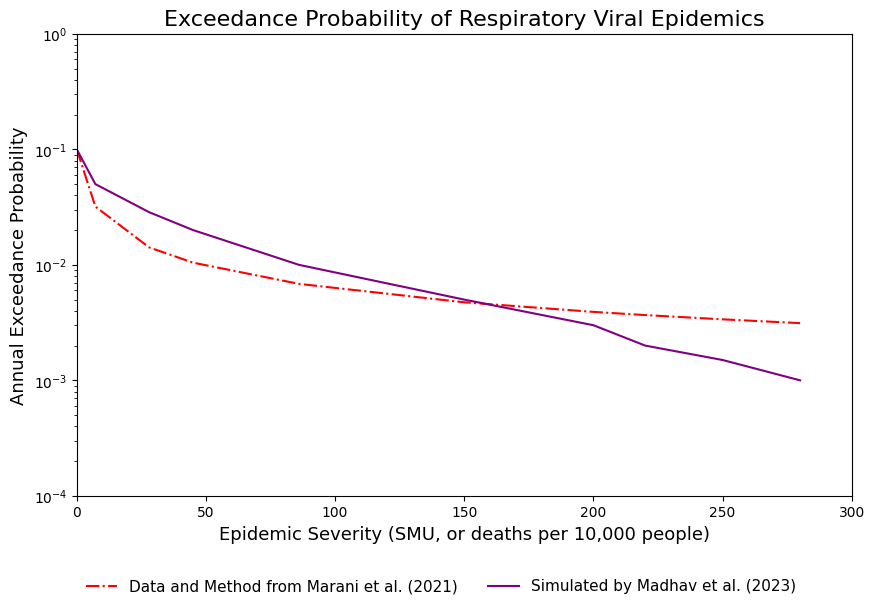

In [22]:
## Plot comparison across Marani et al. and Madhav et al. 
plt.figure(figsize=(10, 6))

## Plot for Marani
plt.plot(df_marani['severity'], df_marani['exceedance'], 
         color='red', linestyle='-.', label='Data and Method from Marani et al. (2021)')

## Plot for Madhav
plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
         color='purple', linestyle='-', label='Simulated by Madhav et al. (2023)')

## Add labels and title
plt.xlabel('Epidemic Severity (SMU, or deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual Exceedance Probability', fontsize=13)
plt.title('Exceedance Probability of Respiratory Viral Epidemics', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis limits
plt.xlim(0, 300)

## Adding legend below the plot in 2 columns without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=2, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig('graphs/03_resp_viral_comp.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


**Note:** The most extreme respiratory viral pandemic (the 1918 influenza pandemic) had a severity of 171 SMUs, while the second most extreme pandemic (the COVID-19 pandemic) only had a severity of 9.2 SMUs. The difference in magnitude and the lack of extreme pandemics with severities between the two may have resulted in a lower exceedance probability calibrated for epidemics 150 SMUs using Marani et al.'s historical data.